# MOML Baseline Demo (10 Configurations)
**Note:** This notebook runs baseline evaluations (20K subset on GPU) to establish the Pareto trade-off space across 10 distinct, representative configurations before running the MOO frameworks.

In [1]:
import torch
import time
import numpy as np
from data_loader import get_dataloaders, get_dataset_info, DEVICE, DEFAULT_TRAIN_SUBSET
from models import build_model, count_parameters, _ARCH_REGISTRY
from train_eval import train_and_evaluate

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Device          : {DEVICE}")
print(f"Train subset    : {DEFAULT_TRAIN_SUBSET:,} samples")

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce GTX 1650
VRAM            : 4.0 GB
Device          : cuda
Train subset    : 20,000 samples


d:\forKrishna\MOML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading
Both datasets loaded locally. CUDA-aware: 20K on GPU, 10K on CPU.

In [2]:
for ds_name in ["cifar10", "fashion_mnist"]:
    info = get_dataset_info(ds_name)
    # Use num_workers=0 to avoid multiprocessing issues on Windows in notebooks
    train_loader, test_loader = get_dataloaders(ds_name, batch_size=64, test_subset_size=500, seed=42, num_workers=0)
    imgs, lbls = next(iter(train_loader))
    
    print(f"\n--- {ds_name} ---")
    print(f"  Classes      : {info['num_classes']}  {info['class_names']}")
    print(f"  Channels     : {info['input_channels']}")
    print(f"  Resolution   : {info['default_resolution']}x{info['default_resolution']}")
    print(f"  Train samples: {len(train_loader.dataset):,}")
    print(f"  Test samples : {len(test_loader.dataset):,}")
    print(f"  Batch shape  : {imgs.shape}")
    print(f"  Pixel range  : [{imgs.min():.3f}, {imgs.max():.3f}]")

d:\forKrishna\MOML\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- cifar10 ---
  Classes      : 10  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Channels     : 3
  Resolution   : 32x32
  Train samples: 20,000
  Test samples : 500
  Batch shape  : torch.Size([64, 3, 32, 32])
  Pixel range  : [-1.989, 2.126]

--- fashion_mnist ---
  Classes      : 10  ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
  Channels     : 1
  Resolution   : 28x28
  Train samples: 20,000
  Test samples : 500
  Batch shape  : torch.Size([64, 1, 28, 28])
  Pixel range  : [-0.810, 2.023]


## 3. Full Baseline Evaluations
Here we evaluate 10 highly distinct configurations representing the full spectrum of our search space.
Since we use `train_subset_size="auto"`, this will run on **20,000 samples** for real measurements.

In [3]:
trial_configs = [
    {"arch_type": "depthwise_separable", "num_conv_layers": 1, "num_channels": 8, "num_fc_units": 32, "learning_rate": 1e-2, "batch_size": 64, "num_epochs": 5, "dropout_rate": 0.0, "optimizer_type": "Adam", "input_resolution": 16},
    {"arch_type": "plain",               "num_conv_layers": 2, "num_channels": 16, "num_fc_units": 64, "learning_rate": 1e-3, "batch_size": 64, "num_epochs": 5, "dropout_rate": 0.0, "optimizer_type": "Adam", "input_resolution": 16},
    {"arch_type": "residual",            "num_conv_layers": 2, "num_channels": 16, "num_fc_units": 64, "learning_rate": 1e-2, "batch_size": 64, "num_epochs": 5, "dropout_rate": 0.1, "optimizer_type": "SGD",  "input_resolution": 16},
    
    {"arch_type": "depthwise_separable", "num_conv_layers": 3, "num_channels": 32, "num_fc_units": 128, "learning_rate": 1e-3, "batch_size": 32, "num_epochs": 10, "dropout_rate": 0.2, "optimizer_type": "Adam", "input_resolution": 32},
    {"arch_type": "plain",               "num_conv_layers": 3, "num_channels": 32, "num_fc_units": 128, "learning_rate": 1e-3, "batch_size": 32, "num_epochs": 10, "dropout_rate": 0.2, "optimizer_type": "Adam", "input_resolution": 32},
    {"arch_type": "residual",            "num_conv_layers": 3, "num_channels": 32, "num_fc_units": 128, "learning_rate": 1e-3, "batch_size": 32, "num_epochs": 10, "dropout_rate": 0.2, "optimizer_type": "Adam", "input_resolution": 32},
    
    {"arch_type": "depthwise_separable", "num_conv_layers": 4, "num_channels": 64, "num_fc_units": 256, "learning_rate": 1e-4, "batch_size": 16, "num_epochs": 15, "dropout_rate": 0.3, "optimizer_type": "Adam", "input_resolution": 32},
    {"arch_type": "plain",               "num_conv_layers": 4, "num_channels": 64, "num_fc_units": 256, "learning_rate": 1e-3, "batch_size": 16, "num_epochs": 15, "dropout_rate": 0.3, "optimizer_type": "Adam", "input_resolution": 32},
    {"arch_type": "residual",            "num_conv_layers": 4, "num_channels": 64, "num_fc_units": 256, "learning_rate": 1e-4, "batch_size": 16, "num_epochs": 15, "dropout_rate": 0.3, "optimizer_type": "Adam", "input_resolution": 32},
    
    {"arch_type": "residual",            "num_conv_layers": 4, "num_channels": 128, "num_fc_units": 256, "learning_rate": 1e-4, "batch_size": 16, "num_epochs": 15, "dropout_rate": 0.4, "optimizer_type": "Adam", "input_resolution": 32},
]

all_results = []

for dataset in ["cifar10", "fashion_mnist"]:
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset}")
    print(f"{'='*70}")
    print(f"{'Arch':>22s} | {'Accuracy':>8s} | {'Infer(ms)':>9s} | {'Params':>10s} | {'Time':>6s}")
    print("-" * 70)
    
    for cfg in trial_configs:
        t0 = time.time()
        # THIS RUNS FULL SIZE (20K ON GPU)
        result = train_and_evaluate(config=cfg, dataset_name=dataset, seed=42, train_subset_size="auto")
        elapsed = time.time() - t0
        
        all_results.append({"dataset": dataset, **cfg, **result})
        
        print(
            f"{cfg['arch_type']:>22s} | "
            f"{result['accuracy']:>7.2%} | "
            f"{result['inference_ms']:>8.3f} | "
            f"{result['param_count']:>10,} | "
            f"{elapsed:>5.1f}s"
        )


Dataset: cifar10
                  Arch | Accuracy | Infer(ms) |     Params |   Time
----------------------------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:19<00:00,  8.05it/s]


   depthwise_separable |  37.63% |    0.725 |      1,042 | 141.8s


Evaluating: 100%|██████████| 157/157 [00:15<00:00, 10.35it/s]


                 plain |  44.44% |    0.297 |      7,946 | 119.9s


...

                 plain |  91.08% |    2.424 |  1,029,514 | 303.5s


Evaluating: 100%|██████████| 625/625 [00:11<00:00, 54.17it/s] 


              residual |  90.63% |    8.671 |  2,545,354 | 481.8s


Evaluating: 100%|██████████| 625/625 [00:16<00:00, 38.87it/s]


              residual |  92.03% |   22.192 | 10,027,658 | 932.4s


### Manual search over params, expected to take 15 hours on laptop GPU

In [4]:
# # %%
# import time
# import itertools
# from train_eval import train_and_evaluate

# # 1. Define your grids
# arch_types       = ["plain", "residual", "depthwise_separable"]
# num_channels     = [16, 64, 128]
# num_fc_units     = [32, 128, 256]
# learning_rates   = [1e-2, 1e-5]
# epochs_list      = [5, 10]
# dropouts         = [0.0, 0.2, 0.5]
# optimizers       = ["Adam", "SGD"]

# # 2. Generate all combinations
# trial_configs = []
# for arch, ch, fc, lr, ep, drop, opt in itertools.product(
#     arch_types, num_channels, num_fc_units, learning_rates, epochs_list, dropouts, optimizers
# ):
#     trial_configs.append({
#         "arch_type": arch,
#         "num_conv_layers": 3,          # Fixed to 3 layers
#         "num_channels": ch,
#         "num_fc_units": fc,
#         "learning_rate": lr,
#         "batch_size": 64,              # Fixed
#         "num_epochs": ep,
#         "dropout_rate": drop,
#         "optimizer_type": opt,
#         "input_resolution": 32         # Fixed
#     })

# print(f"Generated {len(trial_configs)} configurations to test.")

# all_results = []

# # 3. Run the loop
# for dataset in ["cifar10", "fashion_mnist"]:
#     print(f"\n{'='*70}")
#     print(f"Dataset: {dataset}")
#     print(f"{'='*70}")
#     print(f"{'Arch':>22s} | {'Accuracy':>8s} | {'Infer(ms)':>9s} | {'Params':>10s} | {'Time':>6s}")
#     print("-" * 70)
    
#     for cfg in trial_configs:
#         t0 = time.time()
#         # Uses 20K subset if CUDA is available, otherwise 10K
#         result = train_and_evaluate(config=cfg, dataset_name=dataset, seed=42, train_subset_size="auto")
#         elapsed = time.time() - t0
        
#         all_results.append({"dataset": dataset, **cfg, **result})
        
#         print(
#             f"{cfg['arch_type']:>22s} | "
#             f"{result['accuracy']:>7.2%} | "
#             f"{result['inference_ms']:>8.3f} | "
#             f"{result['param_count']:>10,} | "
#             f"{elapsed:>5.1f}s"
#         )


## 4. Trade-off Visualization (The Baseline Pareto Frontier)

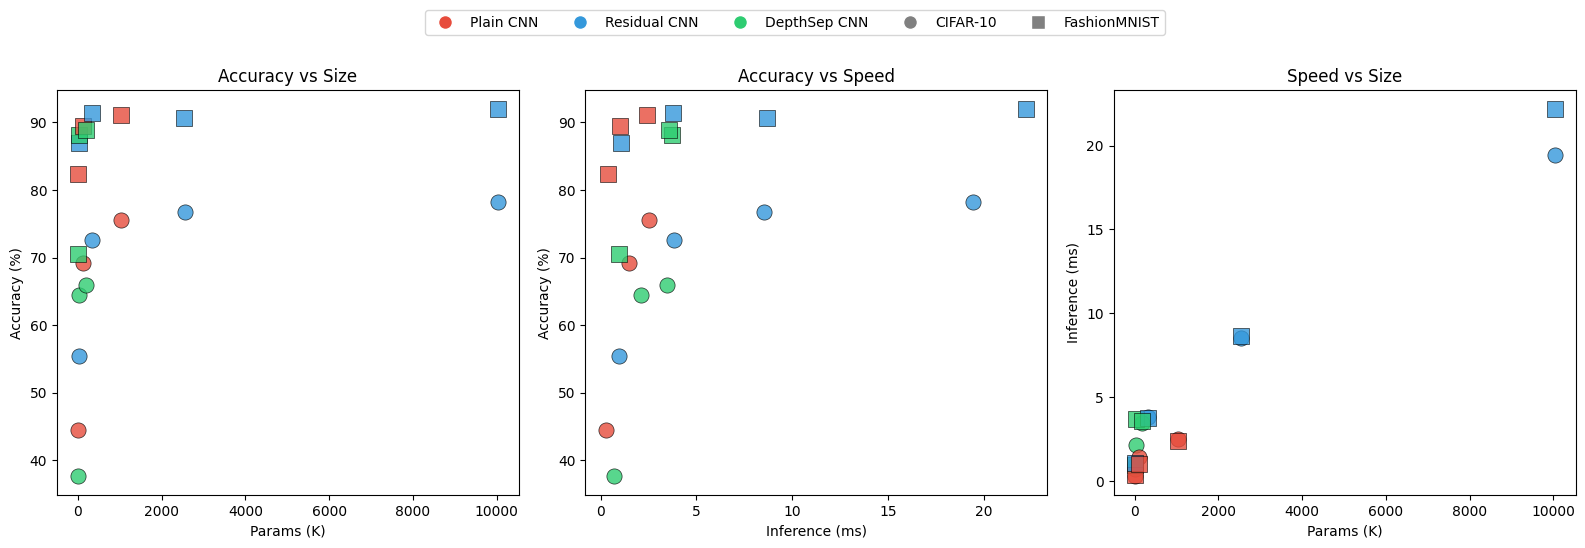

Plot successfully saved as baseline_tradeoffs.png!


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for dataset in ["cifar10", "fashion_mnist"]:
    subset = [r for r in all_results if r["dataset"] == dataset]
    
    accs    = [r["accuracy"] * 100 for r in subset]
    infers  = [r["inference_ms"] for r in subset]
    params  = [r["param_count"] / 1000 for r in subset]  # in K
    labels  = [r["arch_type"] for r in subset]
    colors  = {"plain": "#e74c3c", "residual": "#3498db", "depthwise_separable": "#2ecc71"}
    marker  = "o" if dataset == "cifar10" else "s"
    
    for i, (a, inf, p, lbl) in enumerate(zip(accs, infers, params, labels)):
        axes[0].scatter(p, a, c=colors[lbl], marker=marker, s=120, edgecolors="k", linewidths=0.5, alpha=0.8)
        axes[1].scatter(inf, a, c=colors[lbl], marker=marker, s=120, edgecolors="k", linewidths=0.5, alpha=0.8)
        axes[2].scatter(p, inf, c=colors[lbl], marker=marker, s=120, edgecolors="k", linewidths=0.5, alpha=0.8)

axes[0].set_xlabel("Params (K)"); axes[0].set_ylabel("Accuracy (%)"); axes[0].set_title("Accuracy vs Size")
axes[1].set_xlabel("Inference (ms)"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("Accuracy vs Speed")
axes[2].set_xlabel("Params (K)"); axes[2].set_ylabel("Inference (ms)"); axes[2].set_title("Speed vs Size")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Plain CNN'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Residual CNN'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='DepthSep CNN'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='CIFAR-10'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='FashionMNIST'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()

# Saves the plot to a file in the same directory
plt.savefig("baseline_tradeoffs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot successfully saved as baseline_tradeoffs.png!")